In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin

In [2]:
import numpy as np

h1 = 1
m = 0.5

def coupling(matrix_1, matrix_2):
    s11_1, s12_1 = matrix_1[0, 0], matrix_1[0, 1]
    s21_1, s22_1 = matrix_1[1, 0], matrix_1[1, 1]
    s11_2, s12_2 = matrix_2[0, 0], matrix_2[0, 1]
    s21_2, s22_2 = matrix_2[1, 0], matrix_2[1, 1]
    
    denom = 1 - s11_2 * s22_1
    s11 = s11_1 + s12_1 * s21_1 * s11_2 / denom
    s12 = s12_1 * s12_2 / denom
    s21 = s21_2 * s21_1 / denom
    s22 = s22_2 + s21_2 * s12_2 * s22_1 / denom
    
    return np.array([[s11, s12], [s21, s22]], dtype=np.complex128)

def multiple_coupling(matrix_collect):
    result = matrix_collect[0]
    for matrix in matrix_collect[1:]:
        result = coupling(result, matrix)
    return result

def coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a):
    constant_1 = 2 * m * (y1 + 1j * y2) / (h1**2)
    constant_2 = 2 * m * (y1 - 1j * y2) / (h1**2)
    
    di = np.array([constant_1 if i % 2 == 0 or i >= 2 * N and i < 2 * N + n3 else constant_2 
                   for i in range(2 * N + n3 + n4)], dtype=complex)
    
    x_0 = 0
    x_1 = a * (2 * N + n3 + n4) - a + x_0
    location = np.linspace(x_0, x_1, 2 * N + n3 + n4)
 #   print(location)
    k = np.sqrt(E * 2 * m) / h1
    exp_2jk = np.exp(2j * k * location)
    exp_minus_2jk = np.exp(-2j * k * location)
    
    matrix_collect = np.zeros((2 * N + n3 + n4, 2, 2), dtype=complex)
    for i in range(2 * N + n3 + n4):
        s11 = di[i] * exp_2jk[i]
        s12 = 2j * k
        s21 = 2j * k
        s22 = di[i] * exp_minus_2jk[i]
        
        matrix_collect[i] = np.array([[s11, s12], [s21, s22]]) / (-di[i] + 2j * k)
  #  print(matrix_collect)
    return multiple_coupling(matrix_collect)

def Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[1, 0])**2)

def Reflection_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a):
    matrix = coupling_matrix_of_N_modified(E, y1, y2, N, n3, n4, a)
    return float(np.abs(matrix[0, 0])**2)

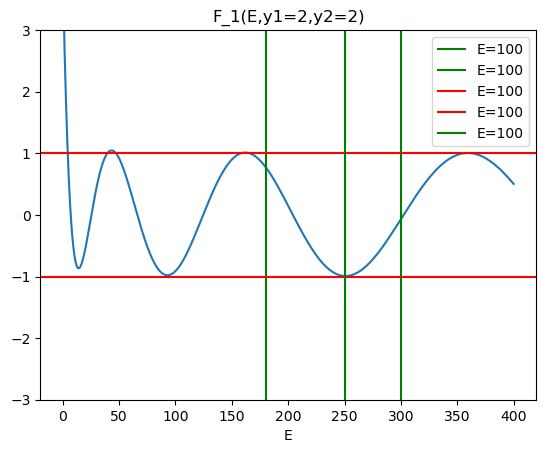

In [6]:
#作图
a=0.5
y1 = 2
y2 = 2
E = np.linspace(0.001, 400, 1000) 
F_values = np.cos(2 * a * np.sqrt(E)) + y1 * np.sin(2 * a * np.sqrt(E)) / np.sqrt(E) - (y1**2 + y2**2) * (np.cos(2 * a * np.sqrt(E)) - 1) / (4 * E)


plt.plot(E, F_values)
plt.ylim(-3,3)
plt.xlabel('E')
plt.title(f'F_1(E,y1={y1},y2={y2})')

#plt.ylabel(f'F_1(E,y1={y1},y2={y2})')
plt.axvline(x=180, color='g', linestyle='-', label='E=100')  # 垂直线
plt.axvline(x=300, color='g', linestyle='-', label='E=100')  # 垂直线
plt.axhline(y=1, color='r', linestyle='-', label='E=100')  # 水平线 ✅ 修正
plt.axhline(y=-1, color='r', linestyle='-', label='E=100')  # 水平线 ✅ 修正
plt.axvline(x=250.76580047607422, color='g', linestyle='-', label='E=100')  # 垂直线
plt.legend()

#plt.grid(True)
plt.show()

In [4]:
##找极值E
def f(E,a,y1,y2):
	return np.cos(2 * a * np.sqrt(E)) + y1 * np.sin(2 * a * np.sqrt(E)) / np.sqrt(E) - (y1**2 + y2**2) * (np.cos(2 * a * np.sqrt(E)) - 1) / (4 * E)
result=fmin(f,250,args=(0.5,2,2))#参数args=(2,3)代表w1=2, w2=3
#result=fmin(f,0.2,args=(2,3),disp=False,xtol=1e-8)
print(result[0])

Optimization terminated successfully.
         Current function value: -0.992056
         Iterations: 18
         Function evaluations: 36
250.76580047607422


In [7]:
250.76580047607422**0.5

15.83558652137881

In [7]:
import numpy as np
from scipy.optimize import root_scalar
from sympy import symbols, parse_expr, lambdify

# 定义参数
a = 0.5
y1 = 2
y2 = 2
y = 250.76580047607422  # 即 E 的值

# 定义符号变量
x, y_sym = symbols('x y')

# 定义隐函数表达式
expr_str = f'cos(x*2*{a}) - cos(sqrt(y)*2*{a}) - 2*{y1}*sin(sqrt(y)*2*{a})/(2*sqrt(y)) + ({y1}**2+{y2}**2)*(cos(sqrt(y)*2*{a}) - 1)/(4*y)'
expr = parse_expr(expr_str)

# 将 SymPy 表达式转换为数值计算的函数
f = lambdify(x, expr.subs(y_sym, y), modules='numpy')

# 定义搜索区间 [0, np.pi/(2a)]
x_min = 0
x_max = np.pi / (2 * a)

# 检查 f(x_min) 和 f(x_max) 是否异号
print(f"f(0) = {f(x_min)}")
print(f"f(pi/(2a)) = {f(x_max)}")

# 使用 root_scalar 求解
try:
    sol = root_scalar(f, bracket=[x_min, x_max], method='brentq')
    if sol.converged:
        x_solution = sol.root
        print(f"Found x = {x_solution} in [0, pi/(2a)]")
    else:
        print("No solution found in the given interval.")
except ValueError as e:
    print(f"Error: {e}")
    print("Trying with a different initial guess...")
    # 使用 fsolve 作为备选方案
    from scipy.optimize import fsolve
    x_guess = (x_min + x_max) / 2  # 初始猜测取中点
    x_solution = fsolve(f, x_guess)[0]
    print(f"Approximate x = {x_solution} (using fsolve)")

f(0) = 1.992055743784565
f(pi/(2a)) = -0.007944256215435042
Found x = 3.015459413798309 in [0, pi/(2a)]


In [ ]:
3.015459413798309
250.76580047607422

In [15]:
#作图
a=0.5
y1 = 2
y2 = 2
n3=0
n4=0
E=250.76580047607422
#N_set = np.linspace(1, 200, 200) 
N_set = np.arange(1, 1001, 1)  
T_minE_N=[Transmission_coefficient_of_N_modified(E, y1, y2, N, n3, n4, a) for N in N_set]



In [18]:
import pandas as pd
import os

In [19]:
# 创建DataFrame保存数据
data = {
    'N_set': N_set,
    'T_set': T_minE_N
}
df = pd.DataFrame(data)

# 创建保存路径
save_dir = r"C:\Users\taoji\Desktop\研究生工作"
os.makedirs(save_dir, exist_ok=True)

# 按参数命名文件
filename = f"第三能带极点处的输运性质.xlsx"
save_path = os.path.join(save_dir, filename)

# 保存到Excel
df.to_excel(save_path, index=False)
print(f"数据已保存至: {save_path}")

数据已保存至: C:\Users\taoji\Desktop\研究生工作\第三能带极点处的输运性质.xlsx


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


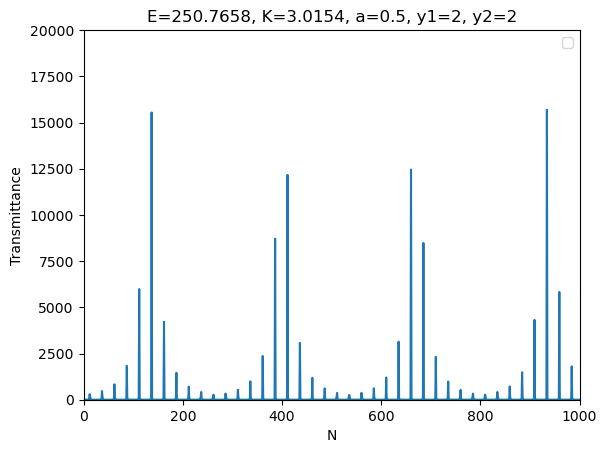

In [42]:
plt.plot(N_set, T_minE_N)
plt.ylim(0,20000)
plt.xlim(0,1000)

plt.xlabel('N')
plt.ylabel('Transmittance')
plt.title(f'E=250.7658, K=3.0154, a=0.5, y1={y1}, y2={y2}')

#plt.ylabel(f'F_1(E,y1={y1},y2={y2})')
plt.axhline(y=1, color='green', linestyle='-', linewidth=1, alpha=0.7)
#plt.axvline(x=300, color='g', linestyle='-', label='E=100')
#plt.axvline(x=250.76580047607422, color='g', linestyle='-', label='E=100')
plt.legend()

save_folder = fr"C:\Users\taoji\Desktop\研究生工作"
image_name = f"第三能带极点处的输运性质_看最大值.png"
save_path = os.path.join(save_folder, image_name)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
#plt.grid(True)
plt.show()

In [39]:
#找最大
zidian=dict(zip(N_set,T_minE_N))
max_key = max(zidian, key=zidian.get)
print(f"最大值的键: {max_key}, 最大值: {zidian[max_key]}")

最大值的键: 934, 最大值: 15690.771294969605


In [40]:
n = 3  # 前3项
sorted_items = sorted(zidian.items(), key=lambda x: x[1], reverse=True)
top_n = sorted_items[:n]

print(f"前{n}大项: {top_n}")

前3大项: [(934, 15690.771294969605), (137, 15544.89050909188), (660, 12452.726740465034)]
